<a href="https://colab.research.google.com/github/MaryamArif85/Saylani_Projects/blob/main/Spam_emaildetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd

In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [39]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])

In [40]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [41]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [42]:
df['label'].value_counts(normalize=True)

,proportion
label,
0,0.865937
1,0.134063


In [43]:
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label'], test_size=0.2, random_state=42) #split data

In [44]:
y_train = y_train.astype('int32')
y_test = y_test.astype('int32')

In [45]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=100)

In [46]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(5000, 16, input_length=100),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_seq, y_train, epochs=5, validation_data=(X_test_seq, y_test), verbose=2)

Epoch 1/5
140/140 - 7s - 53ms/step - accuracy: 0.9152 - loss: 0.2642 - val_accuracy: 0.9776 - val_loss: 0.1023
Epoch 2/5
140/140 - 6s - 40ms/step - accuracy: 0.9821 - loss: 0.0741 - val_accuracy: 0.9901 - val_loss: 0.0481
Epoch 3/5
140/140 - 4s - 32ms/step - accuracy: 0.9908 - loss: 0.0397 - val_accuracy: 0.9767 - val_loss: 0.0667
Epoch 4/5
140/140 - 5s - 32ms/step - accuracy: 0.9937 - loss: 0.0258 - val_accuracy: 0.9919 - val_loss: 0.0343
Epoch 5/5
140/140 - 6s - 40ms/step - accuracy: 0.9964 - loss: 0.0163 - val_accuracy: 0.9928 - val_loss: 0.0339


In [48]:
loss, acc = model.evaluate(X_test_seq, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9928 - loss: 0.0339

Test Accuracy: 99.28%


In [49]:
import numpy as np

In [50]:
max_len = 100

In [51]:
def predict_message(text):
    # Convert text to sequence using the same tokenizer
    seq = tokenizer.texts_to_sequences([text])

    # Pad it to the same length you used in training
    seq_pad = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(seq_pad)[0][0]

    if pred > 0.5:
        print(f"Prediction: SPAM ({pred:.2f})")
    else:
        print(f"Prediction: HAM ({1-pred:.2f})")


predict_message("Congrats! You've won a free iPhone. Click here now")
predict_message("Hey, are we meeting at 5pm today?")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Prediction: SPAM (0.91)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: HAM (1.00)


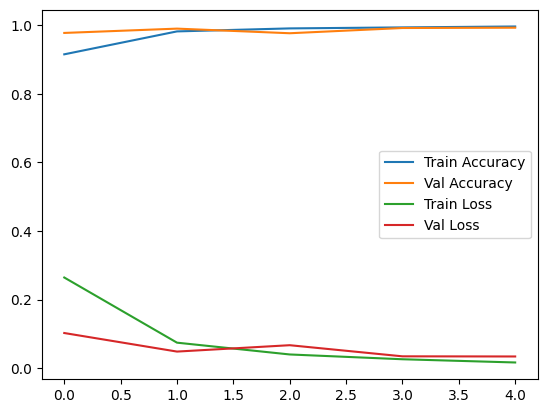

In [52]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [53]:
import joblib

# Save the Keras model
model.save("spam_lstm_model.h5")

# Save the tokenizer and max_len
joblib.dump(tokenizer, "tokenizer.pkl")
joblib.dump(max_len, "max_len.pkl")

['max_len.pkl']